--- imagem original com marcação ---


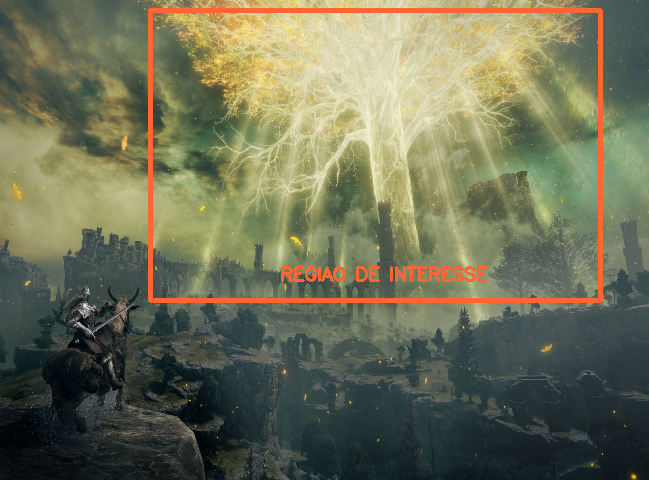


--- imagem em escala de cinza ---


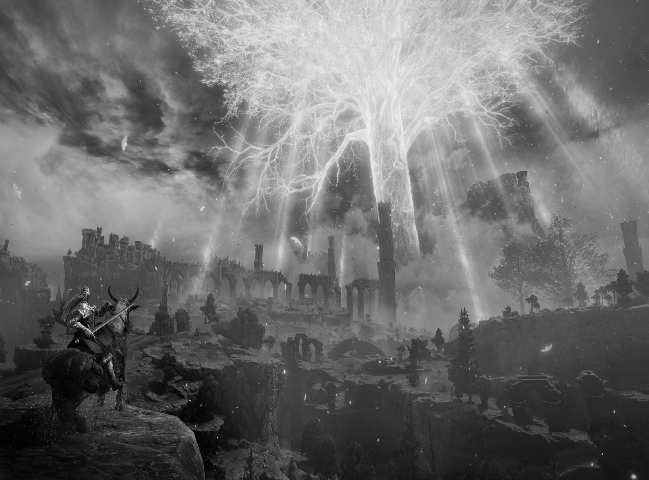

In [7]:
# LEITURA E MODIFICAÇÃO DE IMAGEM ESTÁTICA
import cv2
from google.colab.patches import cv2_imshow
# cv2_imshow - Exclusivo para renderizar imagens no Google Colab

# 1. Carregar a imagem
imagem = cv2.imread('cenario.jpg')

# 2. Redimensiona para uma tamanho padrão de exibição
imagem = cv2.resize(imagem, (649,480))

# 3. Converter para escala de cinza (simplificação matemática da matriz)
imagem_cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

# Parâmetros
cv2.rectangle(imagem, (150, 10), (600, 300), (51, 102, 255), 3)
cv2.putText(
    imagem,
    "REGIAO DE INTERESSE",
    (280, 280),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.6,
    (51, 102, 255),
    2
)

# 4. Exibe os resultados na tela
print("--- imagem original com marcação ---")
cv2_imshow(imagem)

print("\n--- imagem em escala de cinza ---")
cv2_imshow(imagem_cinza)

In [8]:
!pip install easyocr opencv-python

[SISTEMA] Escaneando caracteres da placa...

[SUCESSO] Texto extraído pela IA: BEE4R22

--- Recorte focado enviado para a IA ---


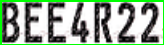


--- Resultado do Sistema de Monitoramento ---


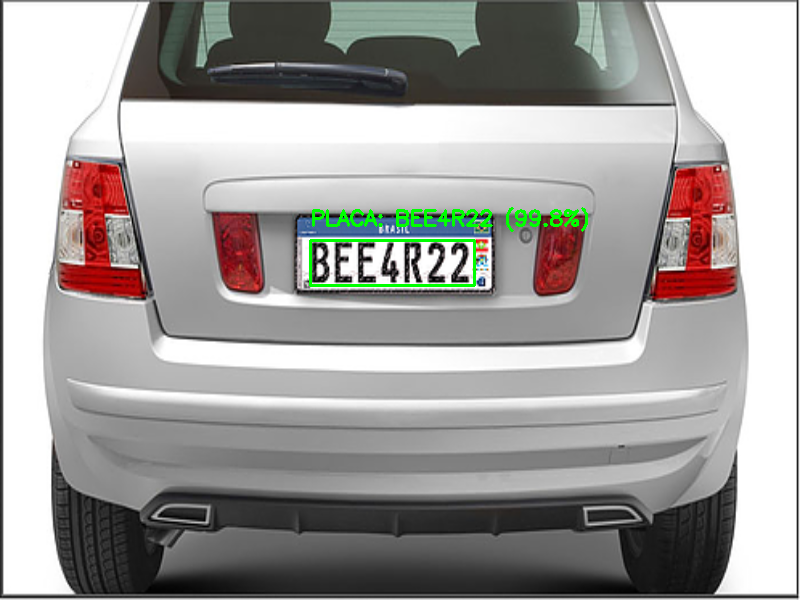

In [106]:
# LEITURA AUTOMÁTICA DE PLACAS
import cv2
import easyocr
from google.colab.patches import cv2_imshow

# 1. Inicializar o leitor OCR da IA para o idioma português
leitor_ocr = easyocr.Reader(['pt'])

# 2. Carregar a imagem do veículo e redimensionar para manter um padrão
imagem_veiculo = cv2.imread('carro.png')
imagem_veiculo = cv2.resize(imagem_veiculo, (800, 600))

# 3. Converter para escala de cinza para facilitar a leitura
imagem_cinza = cv2.cvtColor(imagem_veiculo, cv2.COLOR_BGR2GRAY)

# Coordenadas
x_ini, x_fim = 310, 474
y_ini, y_fim = 240, 285

placa_recortada_cinza = imagem_cinza[y_ini:y_fim, x_ini:x_fim]
placa_recortada_colorida = imagem_veiculo[y_ini:y_fim, x_ini:x_fim]

# 4. Passar o reccorte na IA de OCR para extrair as letras/números
print("[SISTEMA] Escaneando caracteres da placa...")
resultados_ocr = leitor_ocr.readtext(placa_recortada_cinza)

# 5. Extrair o texto encontrado se a IA conseguir ler algo
if len(resultados_ocr) > 0:
    # O resultado do EasyOCR vem no formato:
    # [(coordenadas), "TEXTO_DETECTADO", score_confianca]
    texto_placa = resultados_ocr[0][1].upper().replace(" ", "")
    confianca = resultados_ocr[0][2] * 100

    # Usar o OpenCV para desenhar o resultado na imagem do carro
    cv2.rectangle(
        imagem_veiculo, (x_ini, y_ini), (x_fim, y_fim), (0, 255, 0), 2
    )
    cv2.putText(
        imagem_veiculo, f"PLACA: {texto_placa} ({confianca:.1f}%)",
        (x_ini, y_ini -15), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2
    )
    print(f"\n[SUCESSO] Texto extraído pela IA: {texto_placa}")
else:
    print("\n[ALERTA] Não foi possível decifrar os caracteres")
    print("Ajuste o recorte da ROI.")

# 6. Exibir o painel visual para validação
print("\n--- Recorte focado enviado para a IA ---")
cv2_imshow(placa_recortada_colorida)

print("\n--- Resultado do Sistema de Monitoramento ---")
cv2_imshow(imagem_veiculo)